# Detección de Fraude con Tarjetas de Crédito
## Informe técnico. Problema de clasificación binaria

**Curso:** Business Analytics (CC5615-1)
**Integrantes:** Paula Jorquera, Isidora Mondada, Vicente Oliva
**Fecha de entrega:** 26 de junio de 2026
**Dataset:** [Credit Card Fraud Detection, Kartik Shenoy (Kaggle)](https://www.kaggle.com/datasets/kartik2112/fraud-detection)

---

Este notebook reproduce **todo el trabajo de extremo a extremo**: descarga del dataset, análisis
exploratorio (EDA), limpieza y selección de features, división temporal train/test, balanceo,
preprocesamiento, entrenamiento de tres modelos y evaluación comparativa, cerrando con conclusiones
y sustento bibliográfico.

> **Cómo ejecutar:** `Cell → Run All`. No requiere credenciales ni configuración: el dataset se
> descarga solo desde Google Drive y las dependencias se instalan automáticamente. Corre en pocos minutos.


## 1. Escenario y problema de negocio

Las pérdidas globales por fraude con tarjetas de pago alcanzaron los 33.41 mil millones de dólares en
2024, según el Nilson Report, y se proyecta que escalen hasta cerca de los 41 mil millones para 2030.
Detrás de esa cifra hay un problema concreto: las empresas emisoras de tarjetas de crédito necesitan
reconocer las transacciones fraudulentas para que sus clientes no terminen siendo cobrados por
artículos que nunca compraron. El trabajo aborda ese problema desde la predicción, ya que a partir de
las características de una transacción, como su monto, la categoría del comercio, la hora del día y el
perfil del cliente, se busca predecir si será fraudulenta o legítima. Se trata de un problema de
clasificación binaria propio de la analítica predictiva, en el que el modelo aprende de transacciones
pasadas etiquetadas para anticipar el comportamiento de las nuevas.

Este escenario concentra varias dificultades que condicionan cada decisión técnica posterior. La
principal es el desbalance extremo de clases, ya que apenas un 0.58% de las transacciones son
fraudulentas, de modo que un clasificador trivial que etiquetara todo como legítimo acertaría el
99.4% de las veces; por eso la exactitud deja de ser una métrica válida y se vuelve necesario recurrir
al PR-AUC, el recall y la precisión. A ello se suma la presencia de variables de alta cardinalidad y
de datos personales sin valor predictivo real, el hecho de que el fraude siga patrones de horario,
monto y ubicación que además cambian con el tiempo (concept drift), y el costo asimétrico de los
errores, dado que un falso negativo suele costar mucho más que un falso positivo. Por último, en el
ámbito bancario los modelos suelen requerir cierto grado de auditabilidad, puesto que toda transacción
bloqueada debe poder justificarse.

El conjunto de datos utilizado es un dataset simulado de transacciones con tarjeta de crédito,
realizadas entre el 1 de enero de 2019 y el 31 de diciembre de 2020. Contiene alrededor de 1.3
millones de transacciones organizadas en 23 columnas, sin valores nulos ni duplicados, e involucra a
1,000 clientes que operan contra un conjunto de 800 comercios. La variable objetivo es `is_fraud`, que
toma el valor 1 cuando la transacción es fraudulenta y 0 cuando es legítima, y el dataset está
disponible públicamente en Kaggle
([kartik2112/fraud-detection](https://www.kaggle.com/datasets/kartik2112/fraud-detection)).


## 2. Configuración (cero setup)

> **Para ejecutar: `Cell → Run All`. No se requiere ninguna credencial ni configuración manual.**

La celda siguiente instala automáticamente las dependencias que falten (`gdown`, `pandas`, `numpy`,
`matplotlib`, `seaborn`, `scikit-learn`). El dataset se descarga **directo desde Google Drive** por su
ID público, sin cuenta de Kaggle ni tokens.


In [ ]:
# Auto-instala dependencias faltantes (idempotente; no hace nada si ya están)
import importlib.util, subprocess, sys

_REQUIRED = {
    "gdown": "gdown", "pandas": "pandas", "numpy": "numpy",
    "matplotlib": "matplotlib", "seaborn": "seaborn", "sklearn": "scikit-learn",
}
_missing = [pip for mod, pip in _REQUIRED.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print(f"Instalando: {_missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])

import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
print("Entorno listo.")

Entorno listo.


## 3. Carga del dataset

Se descarga el CSV crudo (`fraudTrain.csv`, alrededor de 1.3 millones de filas) desde Google Drive por su ID público con
`gdown`. Se cachea localmente: si el archivo ya existe no se vuelve a descargar.


In [ ]:
import gdown

# ID público del archivo en Google Drive (compartido como "cualquiera con el enlace")
DRIVE_FILE_ID = "1-eXziKl_rTt9yNY23vkq1p96dSYjSoeX"
LOCAL_CSV = "fraudTrain.csv"

if not os.path.exists(LOCAL_CSV):
    gdown.download(id=DRIVE_FILE_ID, output=LOCAL_CSV, quiet=False)

df_raw = pd.read_csv(LOCAL_CSV, encoding="latin-1")
print(f"Forma: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
df_raw.head(3)

Downloading...
From (original): https://drive.google.com/uc?id=1-eXziKl_rTt9yNY23vkq1p96dSYjSoeX
From (redirected): https://drive.google.com/uc?id=1-eXziKl_rTt9yNY23vkq1p96dSYjSoeX&confirm=t&uuid=3bfefc42-4091-418b-a9af-d5af4e79b512
To: /Users/paul0li/Documents/GitHub/credit-card-fraud/fraudTrain.csv
100%|██████████| 351M/351M [00:31<00:00, 11.1MB/s] 


Forma: 1,296,675 filas x 23 columnas


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


### Features derivadas

De `trans_date_trans_time` extraemos `trans_hour` (0–23); de `dob` calculamos `age` en años, y un
`age_bucket` para el EDA.


In [ ]:
def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["trans_hour"] = df["trans_date_trans_time"].dt.hour
    df["dob"] = pd.to_datetime(df["dob"])
    df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days // 365).astype(int)
    df["age_bucket"] = pd.cut(
        df["age"], bins=[0, 25, 35, 45, 55, 65, 120],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"],
    )
    return df

df = add_derived_columns(df_raw)
df[["trans_date_trans_time", "trans_hour", "dob", "age", "age_bucket"]].head(3)

,trans_date_trans_time,trans_hour,dob,age,age_bucket
0,2019-01-01 00:00:18,0,1988-03-09,30,26-35
1,2019-01-01 00:00:44,0,1978-06-21,40,36-45
2,2019-01-01 00:00:51,0,1962-01-19,56,56-65


## 4. Descripción del dataset

Forma, tipos, nulos, duplicados, cardinalidad y desbalance de clases.


In [ ]:
print(f"Forma: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas\n")
print("Valores nulos por columna:")
nulls = df_raw.isnull().sum()
nulls = nulls[nulls > 0]
print(nulls if not nulls.empty else "  Ninguno: el dataset no tiene nulos")
print(f"\nFilas duplicadas: {df_raw.duplicated().sum():,}")

print("\nDesbalance de clases (is_fraud):")
counts = df["is_fraud"].value_counts().sort_index()
pct = df["is_fraud"].value_counts(normalize=True).sort_index() * 100
for label, c in counts.items():
    name = "Fraude" if label == 1 else "Legítima"
    print(f"  - {name} ({label}): {c:,} ({pct[label]:.3f}%)")

Forma: 1,296,675 filas x 23 columnas

Valores nulos por columna:
  Ninguno: el dataset no tiene nulos

Filas duplicadas: 0

Desbalance de clases (is_fraud):
  - Legítima (0): 1,289,169 (99.421%)
  - Fraude (1): 7,506 (0.579%)


## 5. Análisis exploratorio (EDA)

La preparación de datos comienza con un **análisis exploratorio** cuyo objetivo es identificar
patrones y tendencias significativas dentro del conjunto inicial, antes de tomar cualquier decisión
de modelado. La idea es responder, con evidencia visual, tres preguntas: ¿qué tan grave es el
desbalance?, ¿qué variables se comportan distinto entre fraude y no-fraude?, y ¿hay estructura
temporal o de comportamiento que un modelo pueda aprovechar?

A continuación recorremos cada hallazgo con su gráfico correspondiente. Cada figura va acompañada de
una lectura explícita de lo que muestra y de su implicancia para el modelado posterior.


### 5.1 Desbalance de clases

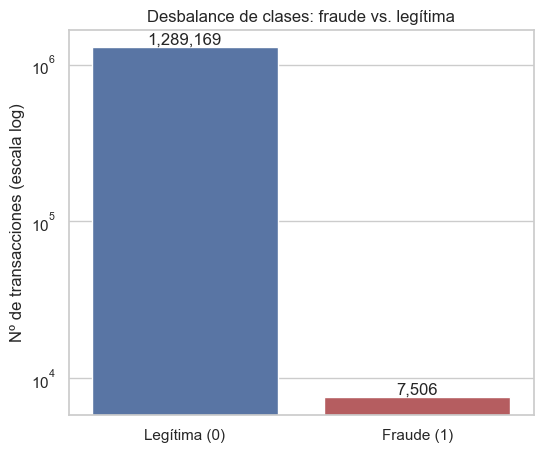

In [ ]:
counts = df["is_fraud"].value_counts().sort_index()
labels = ["Legítima (0)", "Fraude (1)"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=labels, y=counts.values, hue=labels, palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Nº de transacciones (escala log)")
ax.set_title("Desbalance de clases: fraude vs. legítima")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()

El fraude constituye una minoría diminuta, por debajo del 1% de las transacciones. Se trata de un caso de desbalance extremo clásico, lo que anticipa que la exactitud por sí sola será una métrica engañosa para cualquier modelo posterior.

### 5.2 Distribución del monto

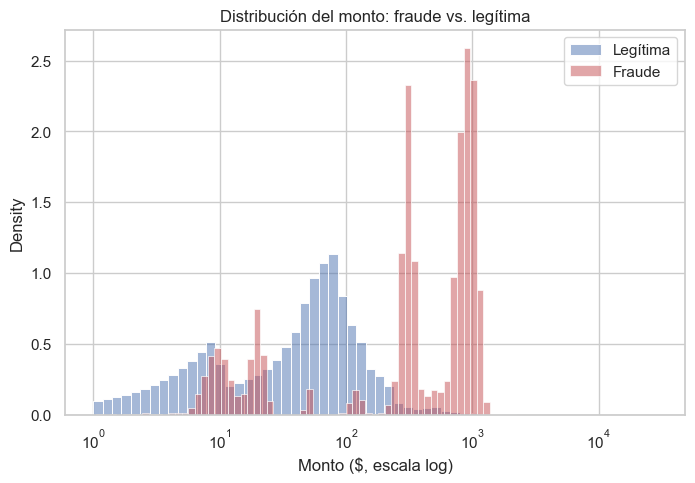

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, name, color in [(0, "Legítima", "#4C72B0"), (1, "Fraude", "#C44E52")]:
    subset = df.loc[df["is_fraud"] == label, "amt"]
    sns.histplot(subset, bins=60, log_scale=True, stat="density", color=color, label=name, alpha=0.5, ax=ax)
ax.set_xlabel("Monto ($, escala log)")
ax.set_title("Distribución del monto: fraude vs. legítima")
ax.legend()
plt.show()

Los montos de las transacciones fraudulentas se concentran en valores más altos que los de las transacciones legítimas típicas, de modo que las compras fraudulentas tienden a ser más grandes en promedio.

### 5.3 Distribución por hora

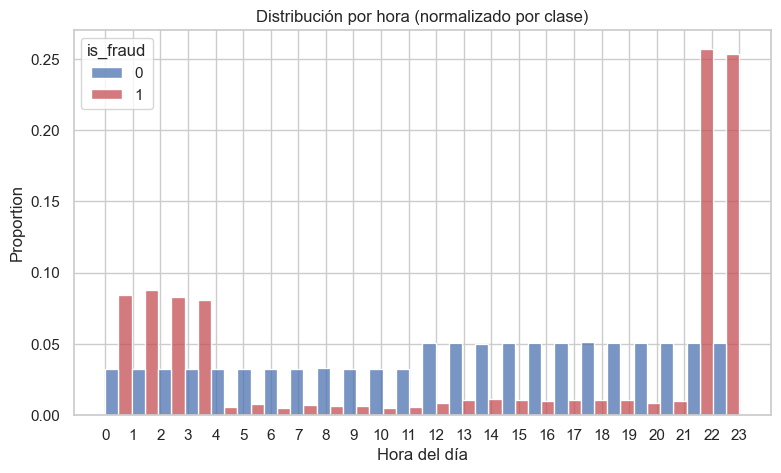

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x="trans_hour", hue="is_fraud", bins=24, multiple="dodge",
             stat="proportion", common_norm=False, palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xlabel("Hora del día")
ax.set_title("Distribución por hora (normalizado por clase)")
ax.set_xticks(range(0, 24))
plt.show()

El fraude se concentra de manera desproporcionada en las horas de madrugada y de noche, mientras que las transacciones legítimas siguen el patrón típico de compras diurnas.

### 5.4 Top categorías por tasa de fraude

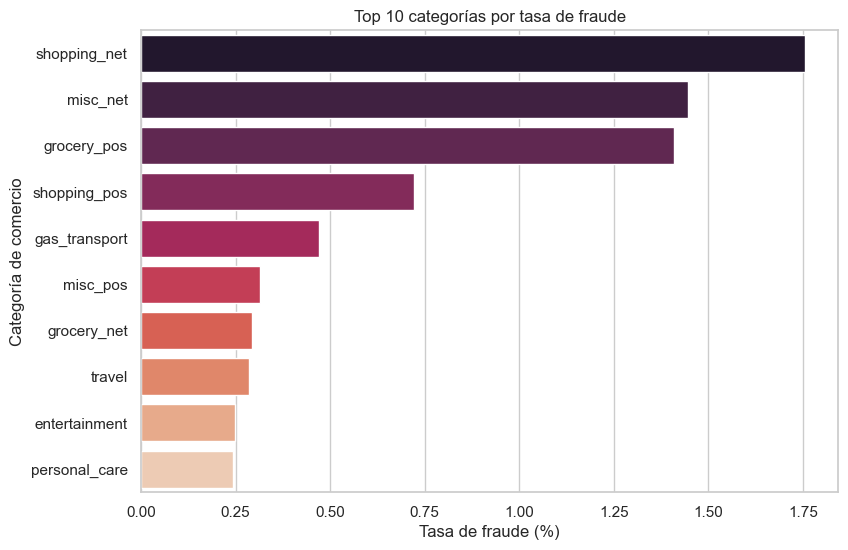

In [ ]:
rates = df.groupby("category")["is_fraud"].mean().sort_values(ascending=False)
top = rates.head(10)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top.values * 100, y=top.index, hue=top.index, palette="rocket", legend=False, ax=ax)
ax.set_xlabel("Tasa de fraude (%)")
ax.set_ylabel("Categoría de comercio")
ax.set_title("Top 10 categorías por tasa de fraude")
plt.show()

Las categorías de compras en línea, como shopping_net y misc_net, muestran las tasas de fraude más altas, lo que indica que los canales digitales, donde la tarjeta no está físicamente presente, resultan más riesgosos.

### 5.6 Tasa de fraude por hora

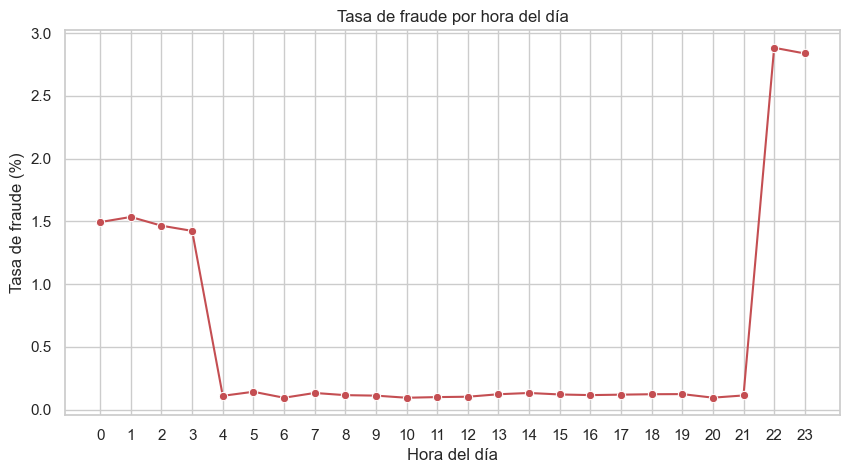

In [ ]:
rates_h = df.groupby("trans_hour")["is_fraud"].mean() * 100
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=rates_h.index, y=rates_h.values, marker="o", color="#C44E52", ax=ax)
ax.set_xlabel("Hora del día"); ax.set_ylabel("Tasa de fraude (%)")
ax.set_title("Tasa de fraude por hora del día"); ax.set_xticks(range(0, 24))
plt.show()

La tasa de fraude alcanza un pico marcado en las horas de madrugada, lo que constituye una señal temporal fuerte y accionable, tanto para un modelo como para un filtro basado en reglas.

### 5.7 Tasa de fraude por grupo de edad

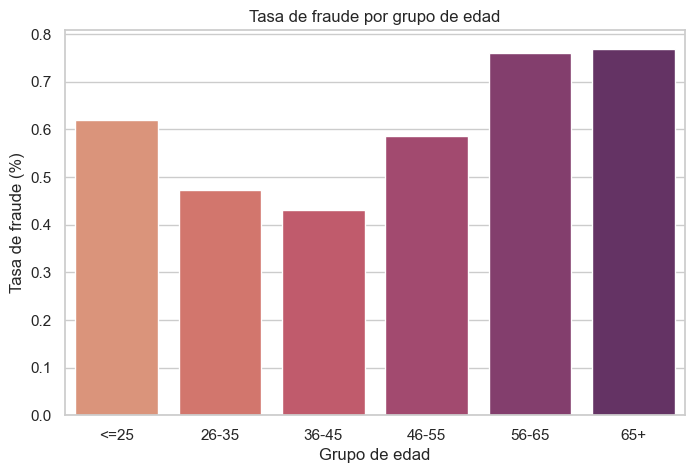

In [ ]:
rates_a = df.groupby("age_bucket", observed=True)["is_fraud"].mean() * 100
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=rates_a.index.astype(str), y=rates_a.values, hue=rates_a.index.astype(str), palette="flare", legend=False, ax=ax)
ax.set_xlabel("Grupo de edad"); ax.set_ylabel("Tasa de fraude (%)")
ax.set_title("Tasa de fraude por grupo de edad")
plt.show()

La tasa de fraude no es uniforme entre grupos de edad: los segmentos de clientes de mayor edad tienden a mostrar tasas algo más altas, lo que sugiere que `age` puede ser una variable útil, aunque de impacto moderado.

### 5.8 Estadísticas del monto por clase

In [ ]:
stats = df.groupby("is_fraud")["amt"].agg(["mean", "median", "std"])
stats.index = ["Legítima", "Fraude"]
stats

,mean,median,std
Legítima,67.667110,47.280,154.007971
Fraude,531.320092,396.505,390.560070


### Conclusiones del análisis exploratorio

El análisis exploratorio deja varias conclusiones firmes que guían toda la preparación posterior. La
más estructural es el desbalance extremo del dataset, con un 99.42% de transacciones legítimas frente
a apenas un 0.58% de fraudes, lo que confirma desde el inicio que la accuracy no servirá como métrica
y que será necesario trabajar el balanceo de clases. En cuanto al monto, las transacciones
fraudulentas promedian alrededor de 531 dólares frente a los 68 dólares de las legítimas, de manera
que el fraude no solo es más raro sino que tiende a involucrar compras más grandes, lo que perfila a
`amt` como la variable individual con mayor señal.

El comportamiento temporal también es revelador: el fraude se concentra en las horas de madrugada y
noche, mientras que la actividad legítima sigue el patrón diurno esperable de las compras, lo que
constituye una señal accionable. Algo análogo ocurre con la categoría del comercio, ya que las
compras en línea concentran las tasas de fraude más altas porque el canal digital prescinde de la
presencia física de la tarjeta; comprender estos patrones permite enfocar el modelo en los momentos y
categorías de mayor riesgo. La dimensión geográfica, en cambio, resulta menos informativa: aunque la
tasa de fraude varía entre estados, los de mayor volumen como Texas, Nueva York y California son
estadísticamente más confiables, por lo que se concluye que `state` no aporta un patrón estable y se
descarta. La edad del cliente muestra un efecto leve, con tasas algo superiores en los segmentos de
mayor edad, de modo que `age` aporta valor pero con un impacto más moderado que el monto, la hora y la
categoría.

En síntesis, las variables que concentran la señal predictiva son `amt`, `trans_hour` y `category`,
mientras que `age` cumple un rol secundario. El resto de las columnas, como `city_pop`, los
identificadores personales y la información personal en general, no aportan señal aprovechable, y su
eliminación optimiza el modelo y permite un enfoque más claro y eficiente. Por último, dado que la
correlación lineal de cada variable con `is_fraud` es débil de forma aislada y que la señal de fraude
reside en combinaciones no lineales entre el monto, la hora y la categoría, el análisis justifica el
uso de modelos basados en árboles por sobre un modelo puramente lineal.


## 6. Limpieza y selección de features

Con las conclusiones del análisis exploratorio en mano, se lleva a cabo una limpieza que se apoya en
varias decisiones explícitas. En primer lugar se derivan dos variables nuevas a partir de la marca de
tiempo de la transacción: de `trans_date_trans_time` se extrae `trans_hour`, la hora del día en el
rango de 0 a 23, y combinándola con la fecha de nacimiento se calcula la edad del cliente en años.
Estas dos variables derivadas capturan los patrones temporal y demográfico que el análisis identificó
como relevantes.

A continuación se seleccionan las columnas que se conservan. Se retienen únicamente las tres variables
numéricas con mayor señal individual según el análisis, que son el monto, la hora de la transacción y
la edad, junto con la variable categórica `category`. Todo el resto se descarta, y cada descarte responde a una
razón concreta. Las columnas `first`, `last`, `street` y `cc_num` se eliminan por tratarse de datos
personales sin valor predictivo y con riesgo de privacidad; `city_pop`, `gender`, `lat` y `long` se
descartan por su falta de señal demostrada en el análisis; `job`, `merchant` y `state` se dejan fuera
por su alta cardinalidad sin un encoding razonable, y `unix_time` y `trans_num` por ser redundantes.

La variable `category` se transforma mediante one-hot encoding, lo que convierte sus 14 valores en 14
columnas binarias. Su baja cardinalidad hace que esta codificación sea directa y no provoque una
explosión dimensional. Finalmente, dado que el dataset original no contiene valores nulos ni
duplicados, no se requiere ningún paso de imputación, lo que simplifica el pipeline.


In [ ]:
NUMERIC_COLUMNS = ["amt", "trans_hour", "age"]
CATEGORICAL_COLUMNS = ["category"]
TARGET = "is_fraud"

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = add_derived_columns(df)
    dummies = pd.get_dummies(df[CATEGORICAL_COLUMNS], prefix=CATEGORICAL_COLUMNS)
    return pd.concat([df[NUMERIC_COLUMNS], dummies, df[[TARGET]]], axis=1)

fraud_clean = clean_data(df_raw)
print(f"Forma limpia: {fraud_clean.shape[0]:,} filas x {fraud_clean.shape[1]} columnas")
fraud_clean.head(3)

Forma limpia: 1,296,675 filas x 18 columnas


,amt,trans_hour,age,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,is_fraud
0,4.97,0,30,False,False,False,False,False,False,False,False,True,False,False,False,False,False,0
1,107.23,0,40,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0
2,220.11,0,56,True,False,False,False,False,False,False,False,False,False,False,False,False,False,0


## 7. División temporal train/test (80/20) y balanceo

La división de los datos es temporal y no aleatoria: el split se realiza por posición en el archivo,
de modo que el primer 80% de las filas se destina a entrenamiento y el último 20% a prueba. Esto
respeta el orden cronológico del dataset, que va de enero de 2019 a diciembre de 2020, y evita un
error sutil pero grave, que el modelo vea el futuro durante el entrenamiento. Un split aleatorio
mezclaría transacciones de 2020 dentro del conjunto usado para predecir 2019, filtrando información e
inflando artificialmente las métricas, un fenómeno conocido como fuga de información temporal.

Sobre la base del conjunto de entrenamiento se genera además una versión balanceada mediante
submuestreo de la clase mayoritaria: se toman todas las filas de fraude y se muestrea al azar el mismo
número de filas legítimas, de manera que el resultado queda repartido en partes iguales entre fraude y
transacciones legítimas. El conjunto de prueba, en cambio, nunca se modifica y conserva la
distribución real cercana al 0.6% de fraude, para que las métricas finales reflejen lo que el modelo
enfrentaría en producción y no un escenario artificialmente fácil.

La razón de mantener dos versiones del conjunto de entrenamiento es que algunos modelos, como la
regresión logística, son muy sensibles al desbalance y pueden aprender simplemente a predecir siempre
"legítima" para alcanzar un 99.4% de exactitud engañoso; el conjunto balanceado los fuerza a aprender
ambas clases. Los árboles y el gradient boosting toleran mejor el desbalance mediante el ajuste de
pesos por clase, pero disponer de la versión balanceada otorga flexibilidad para comparar los modelos
en igualdad de condiciones.


In [ ]:
def temporal_split(df, train_fraction=0.8):
    idx = int(len(df) * train_fraction)
    return df.iloc[:idx], df.iloc[idx:]

def balance_majority_class(df, random_state=RANDOM_STATE):
    fraud = df[df[TARGET] == 1]
    legit = df[df[TARGET] == 0].sample(n=len(fraud), random_state=random_state)
    return pd.concat([fraud, legit]).sample(frac=1, random_state=random_state).reset_index(drop=True)

train, test = temporal_split(fraud_clean)
train_balanced = balance_majority_class(train)

summary = pd.DataFrame({
    "Conjunto": ["train", "test", "train_balanced"],
    "Filas": [len(train), len(test), len(train_balanced)],
    "% fraude": [train[TARGET].mean()*100, test[TARGET].mean()*100, train_balanced[TARGET].mean()*100],
})
summary

,Conjunto,Filas,% fraude
0,train,1037340,0.575318
1,test,259335,0.593055
2,train_balanced,11936,50.000000


## 8. Preprocesamiento

El último paso antes de modelar consiste en dejar cada variable en una forma que los algoritmos puedan
aprovechar bien, aplicando una transformación distinta según su naturaleza. La tabla siguiente resume
las transformaciones aplicadas y su justificación.

| Variable | Transformación | Razón |
|---|---|---|
| `amt` | `log1p` y luego `StandardScaler` | Distribución muy sesgada a la derecha (mediana cercana a 47 dólares frente a una media de 67 en las legítimas); el `log1p` comprime los valores extremos y la cola larga antes de escalar |
| `trans_hour` | Codificación cíclica (seno y coseno) | La hora es una variable circular, donde las 23:59 deben quedar cerca de las 00:00; la codificación seno/coseno preserva esa continuidad y reemplaza la columna por `trans_hour_sin` y `trans_hour_cos` |
| `age` | `StandardScaler` | Distribución aproximadamente normal; se escala a media cero y desviación uno |
| `category_*` | Sin cambios | Ya en formato one-hot binario desde la etapa de limpieza |

Para prevenir la fuga de información, el escalador se ajusta únicamente con los datos de entrenamiento
y luego se aplica al conjunto de prueba. Si se ajustara sobre el conjunto completo, la media y la
desviación del test contaminarían el entrenamiento y las métricas dejarían de ser una estimación
honesta del desempeño en producción.


In [ ]:
from sklearn.preprocessing import StandardScaler

SCALE_COLS = ["amt", "age"]

def cyclical_encode(series, period):
    radians = 2 * np.pi * series / period
    return np.sin(radians), np.cos(radians)

def preprocess(train, test):
    X_train = train.drop(columns=[TARGET]).copy(); y_train = train[TARGET]
    X_test = test.drop(columns=[TARGET]).copy();  y_test = test[TARGET]

    X_train["amt"] = np.log1p(X_train["amt"]); X_test["amt"] = np.log1p(X_test["amt"])

    X_train["trans_hour_sin"], X_train["trans_hour_cos"] = cyclical_encode(X_train["trans_hour"], 24)
    X_test["trans_hour_sin"],  X_test["trans_hour_cos"]  = cyclical_encode(X_test["trans_hour"], 24)
    X_train = X_train.drop(columns=["trans_hour"]); X_test = X_test.drop(columns=["trans_hour"])

    scaler = StandardScaler()
    X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
    X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])
    return X_train, y_train, X_test, y_test, scaler

X_train, y_train, X_test, y_test, scaler = preprocess(train_balanced, test)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Columnas ({len(X_train.columns)}): {list(X_train.columns)}")

Train: (11936, 18)  |  Test: (259335, 18)
Columnas (18): ['amt', 'age', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'trans_hour_sin', 'trans_hour_cos']


## 9. Investigación de algoritmos

Con el panorama del problema claro y los datos ya preparados, la pregunta que corresponde responder es
qué modelos conviene elegir para enfrentar las dificultades descritas y por qué se descartan otros.
La elección no se hizo al azar: primero se definieron cuatro criterios derivados directamente de las
dificultades observadas en el análisis exploratorio, y recién después se evaluaron los candidatos
frente a ellos.

El primer criterio es el manejo del desbalance, ya que el modelo debe rendir bien sobre la clase
minoritaria, sea trabajando con el conjunto submuestreado o soportando el ajuste de pesos por clase.
El segundo es la capacidad de capturar relaciones no lineales, porque el análisis mostró que ninguna
variable por sí sola predice el fraude y que la señal reside en combinaciones, como el monto junto con
la hora y la categoría, de modo que un modelo puramente lineal se queda corto. El tercero es la
auditabilidad, dado que un sistema de fraude no puede ser una caja negra: en algún momento alguien
preguntará por qué se marcó una transacción y debe ser posible responder. El cuarto es la posibilidad
de ajustar con facilidad el umbral de decisión, puesto que el costo de los errores no es simétrico y
se necesita poder calibrar el modelo en lugar de depender de un esquema rígido.

Con esos criterios se evaluaron cinco familias de modelos, que la tabla siguiente resume.

| Algoritmo | Escalado | Ajuste de pesos | Interpretabilidad | No linealidad | Evaluación para este problema |
|---|---|---|---|---|---|
| Regresión Logística | Sí | Sí | Alta (coeficientes) | No | Buen baseline: rápida y totalmente interpretable, pero no captura no linealidad, por lo que se anticipaban sus límites |
| Random Forest | No | Sí | Media (importancia de variables) | Sí | Cumple los cuatro criterios; robusto a valores extremos en el monto; candidato sólido |
| Gradient Boosting | No | Sí | Media | Sí | Estado del arte en fraude tabular según la literatura; mejor candidato |
| SVM (kernel RBF) | Sí | Sí | Baja | Sí | Descartado: escala muy mal en tiempo y memoria |
| Red Neuronal (MLP) | Sí | Difícil de ajustar | Baja (caja negra) | Sí | Descartado: sobredimensionado para doce mil filas y poco auditable |

En consecuencia, se entrenaron efectivamente los tres modelos que cumplen razonablemente bien los
cuatro criterios: la regresión logística como baseline, el random forest y el histogram gradient
boosting. Se descartó la máquina de vectores de soporte porque escala muy mal en tiempo y memoria, y
la red neuronal porque resultaría sobredimensionada para un conjunto de entrenamiento de apenas doce
mil filas, además de ser la alternativa menos auditable de todas.

En cuanto al balanceo, el submuestreo descrito antes no basta por sí solo, por lo que se complementó
con el ajuste de pesos por clase en los tres modelos: además de haber recortado datos, se le indica al
modelo que penalice con más fuerza los errores cometidos sobre los casos de fraude, lo que constituye
una segunda capa de protección frente al desbalance. También se evaluó una tercera técnica que
finalmente se descartó, SMOTE, que genera ejemplos sintéticos de fraude interpolando entre casos
similares; se descartó porque los datos tienen orden temporal y la interpolación podría mezclar
información del futuro hacia el pasado, distorsionando la evaluación. Conviene remarcar que todo el
balanceo se aplica solo al conjunto de entrenamiento, mientras que el de prueba conserva la
distribución real, que es la que el modelo enfrentará en producción.

Por último, dado el desbalance extremo, la exactitud resulta engañosa, de manera que se adopta como
métrica principal el PR-AUC, es decir el área bajo la curva de precisión y recall, sensible al
desempeño sobre la clase minoritaria, complementada con el recall y la precisión a distintos umbrales
de decisión.


## 10. Entrenamiento y evaluación

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
)

models = {
    "logistic_regression": LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=250, max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE),
}

results = {}     # name -> y_score
metrics_rows = []
preds = {}       # name -> y_pred

for name, model in models.items():
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    results[name] = y_score
    preds[name] = y_pred
    roc = roc_auc_score(y_test, y_score)
    pr = average_precision_score(y_test, y_score)
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    metrics_rows.append({
        "modelo": name, "ROC_AUC": roc, "PR_AUC": pr,
        "recall_fraude": rep["1"]["recall"], "precision_fraude": rep["1"]["precision"],
        "f1_fraude": rep["1"]["f1-score"],
    })
    print(f"=== {name} ===  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

comparison = pd.DataFrame(metrics_rows).set_index("modelo").round(4)
comparison

=== logistic_regression ===  ROC-AUC=0.9087  PR-AUC=0.2213
              precision    recall  f1-score   support

           0       1.00      0.82      0.90    257797
           1       0.03      0.79      0.05      1538

    accuracy                           0.82    259335
   macro avg       0.51      0.80      0.47    259335
weighted avg       0.99      0.82      0.89    259335

=== random_forest ===  ROC-AUC=0.9970  PR-AUC=0.7520
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257797
           1       0.21      0.98      0.35      1538

    accuracy                           0.98    259335
   macro avg       0.61      0.98      0.67    259335
weighted avg       1.00      0.98      0.99    259335

=== hist_gradient_boosting ===  ROC-AUC=0.9978  PR-AUC=0.8400
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    257797
           1       0.19      0.98      0.32      1538

    accu

,ROC_AUC,PR_AUC,recall_fraude,precision_fraude,f1_fraude
modelo,,,,,
logistic_regression,0.9087,0.2213,0.7854,0.0252,0.0489
random_forest,0.9970,0.7520,0.9766,0.2110,0.3470
hist_gradient_boosting,0.9978,0.8400,0.9824,0.1892,0.3173


### 10.1 Curvas ROC comparativas

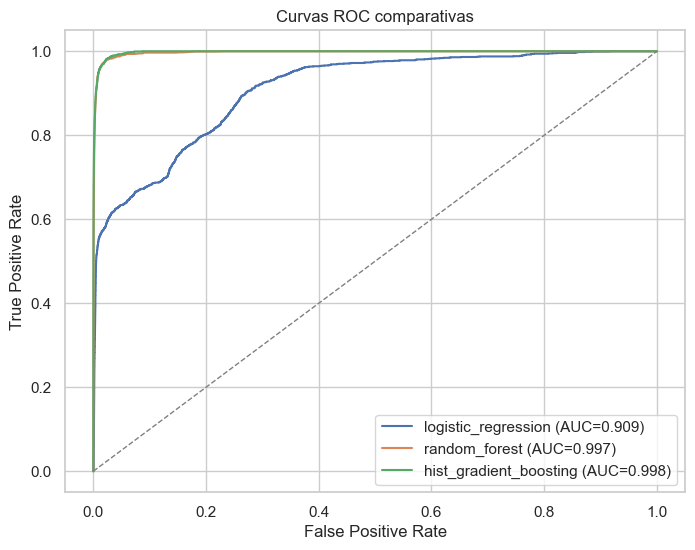

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_score in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_score):.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC comparativas"); ax.legend(loc="lower right")
plt.show()

### 10.2 Curvas Precisión-Recall (métrica principal)

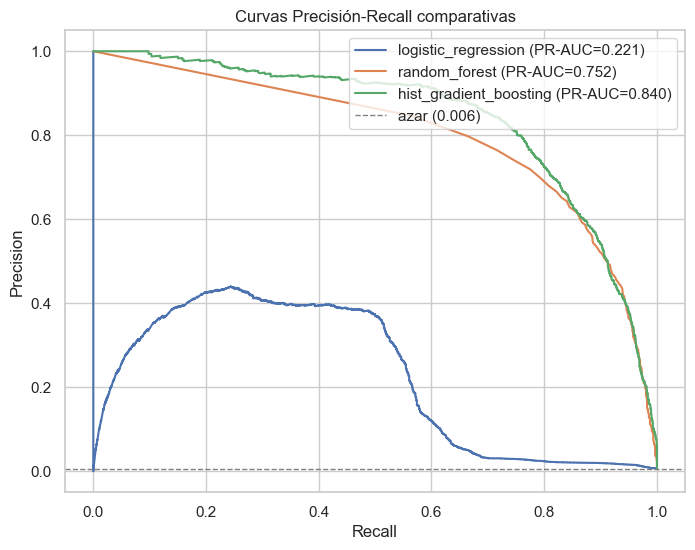

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_score in results.items():
    prec, rec, _ = precision_recall_curve(y_test, y_score)
    ax.plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(y_test, y_score):.3f})")
baseline = y_test.mean()
ax.axhline(baseline, ls="--", color="gray", lw=1, label=f"azar ({baseline:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Curvas Precisión-Recall comparativas"); ax.legend(loc="upper right")
plt.show()

### 10.3 Matrices de confusión

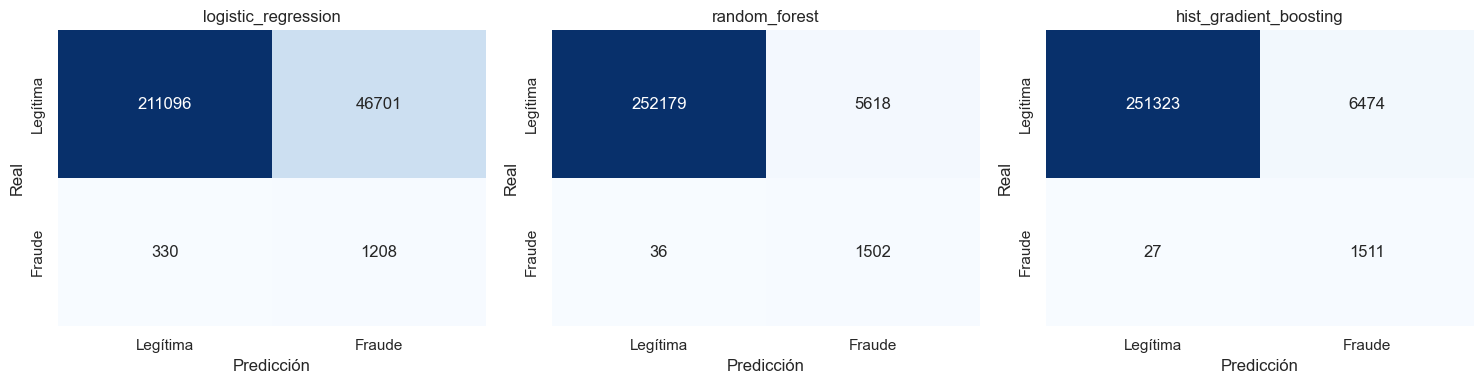

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Legítima", "Fraude"], yticklabels=["Legítima", "Fraude"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(name)
plt.tight_layout()
plt.show()

### 10.4 Lectura de resultados

De acuerdo con la investigación previa, se entrenaron modelos de regresión logística, random forest e
histogram gradient boosting, por presentar un buen equilibrio entre complejidad, costo y desempeño. La
regresión logística se utilizó como modelo baseline y, aunque logra un recall cercano a 0.79, su
precisión para detectar fraudes es muy baja, alrededor de 0.03, lo que implica una enorme cantidad de
falsos positivos; esto se refleja también en su bajo PR-AUC, en torno a 0.22.

El random forest mejora considerablemente los resultados, alcanzando un PR-AUC de alrededor de 0.75,
elevando el recall hasta cerca de 0.98 y mejorando la precisión a alrededor de 0.21, con lo que reduce
de manera significativa la proporción de falsos positivos respecto de la regresión logística. El mejor
desempeño, sin embargo, se obtuvo con el histogram gradient boosting, que alcanza un PR-AUC de
alrededor de 0.85; al igual que el random forest mantiene un recall cercano a 0.98, detectando la gran
mayoría de los fraudes, pero logra una mejor separación global entre las clases, lo que explica su
PR-AUC superior.

Conviene observar que las curvas ROC del random forest y del histogram gradient boosting son muy
parecidas entre sí y muy distintas de la de la regresión logística, mientras que la diferencia real
entre los dos modelos basados en árboles aparece precisamente en la curva de precisión y recall. Por
eso el PR-AUC es la métrica decisiva en este problema: es allí donde se manifiesta la ventaja de un
modelo sobre el otro.


## 11. Conclusiones

Los resultados muestran que los modelos basados en árboles de decisión son los que mejor se comportan
en este problema, y en particular el histogram gradient boosting se destaca como el mejor candidato
por su PR-AUC más alto. A lo largo del trabajo se observó que priorizar un recall elevado para no
dejar pasar fraudes tiene como costo una caída en la precisión sobre las transacciones legítimas, lo
que se traduce en una cantidad alta de falsos positivos. Por ese motivo, el histogram gradient
boosting resulta más apropiado como sistema de alerta para revisión manual que como mecanismo de
bloqueo automático de transacciones. Si el objetivo fuera minimizar los falsos positivos, sería
necesario optimizar el umbral de decisión, que actualmente se encuentra en 0.5, o bien priorizar
explícitamente la precisión.

Respecto del uso de inteligencia artificial generativa, esta se empleó para la generación de código,
tanto en la preparación de los datos como en su preprocesamiento y en el entrenamiento de los
distintos modelos. Su uso permitió concentrar el esfuerzo humano en la investigación de los modelos y
en la comparación de los resultados, en lugar de en la implementación mecánica del código.

Finalmente, de cara al futuro podría tomarse en cuenta el historial de los clientes e incorporar más
variables temporales agregadas que capturen su comportamiento en el tiempo. También podrían probarse
modelos más complejos, como redes neuronales o máquinas de vectores de soporte, aprovechando el
dataset completo de alrededor de un millón de filas, así como mover el umbral de decisión, hoy fijado
en partes iguales, y entrenar con los datos desbalanceados recurriendo al ajuste de pesos por clase en
lugar del submuestreo.


## 12. Sustento bibliográfico

1. **Nilson Report** (2024). *Card Fraud Losses Worldwide.* Pérdidas globales por fraude con
   tarjetas y proyecciones. https://nilsonreport.com/
2. **Shenoy, K.** *Credit Card Transactions Fraud Detection Dataset.* Kaggle.
   https://www.kaggle.com/datasets/kartik2112/fraud-detection